--- Data Overview ---
   0    Stream  Zscore           3            4     5                  6  7  \
0  0      ARTS  -.3550  4336 (NEW)  64994 (NEW)  2020  POLITICAL SCIENCE  S   
1  1      ARTS  -.2648  4154 (NEW)  62338 (NEW)  2020  POLITICAL SCIENCE  S   
2  2  COMMERCE  -.4760  6910 (NEW)  37307 (NEW)  2020          ECONOMICS  S   
3  3  COMMERCE  -.1012  5678 (NEW)  30449 (NEW)  2020          ECONOMICS  C   
4  4  COMMERCE   .6014  3269 (NEW)  17010 (NEW)  2020          ECONOMICS  C   

                   8  9          10 11   12 13   14  15       16    17  Gender  
0  DANCING(BHARATHA)  C       TAMIL  S  056  S  new  31      May  2001  female  
1     CARNATIC MUSIC  C       TAMIL  C  032  C  new  13  January  2002  female  
2   BUSINESS STUDIES  S  ACCOUNTING  S  050  S  new  16   August  2001  female  
3   BUSINESS STUDIES  C  ACCOUNTING  S  034  S  new  16   August  2001  female  
4   BUSINESS STUDIES  C  ACCOUNTING  B  036  S  new   7   August  2000  female  

--- DataFrame In

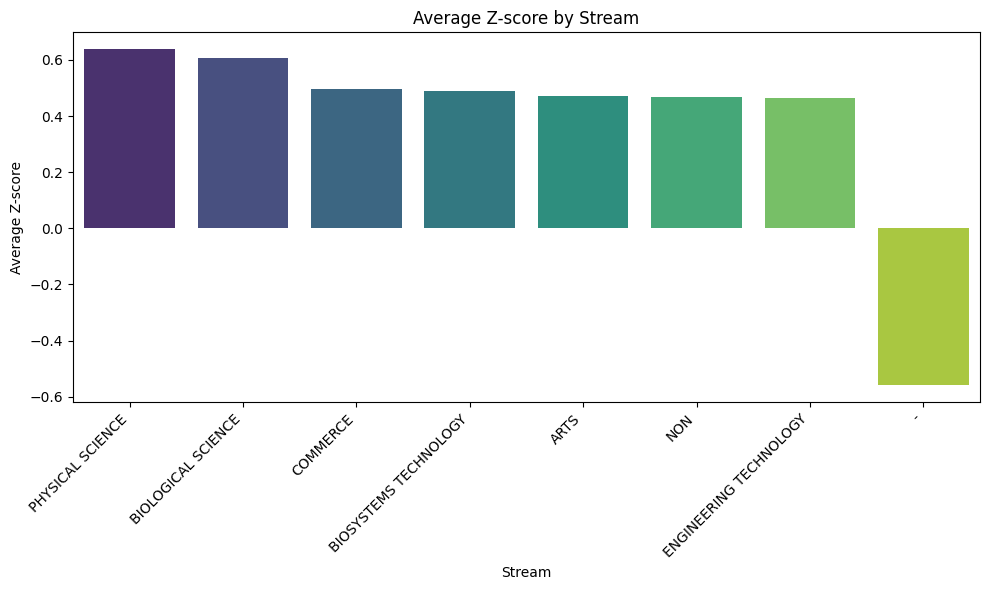

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. EXTRACT ---
# Read the uploaded CSV file, skipping the first row (which appears to be metadata or a problematic header)
# and assuming comma as delimiter. No header in the data rows themselves.
file_path = uploaded_file_name # Use the name of the uploaded file
df = pd.read_csv(file_path, sep=',', header=None, skiprows=[0])

# Rename columns based on the expected structure of the dataset
# Assuming column 1 (index 0) is 'Student Id',
# column 2 (index 1) is 'Stream',
# column 3 (index 2) is 'Zscore'.
# Column 18 (index 18) is 'Gender'.
df.rename(columns={1: 'Stream', 2: 'Zscore', 18: 'Gender'}, inplace=True)

print("--- Data Overview ---")
print(df.head()) # Display the first 5 rows
print("\n--- DataFrame Info ---")
df.info()


# --- 2. TRANSFORM ---
# 1. Convert 'Zscore' to numeric, coercing errors to NaN
df['Zscore'] = pd.to_numeric(df['Zscore'], errors='coerce')

# 2. Remove missing values (NaNs) from 'Stream' and 'Zscore' to ensure clean analysis
df_clean = df.dropna(subset=['Stream', 'Zscore', 'Gender']).copy()


# --- 3. LOAD / ANALYTICS ---
# Group data by 'Stream' and calculate the mean 'Zscore'
analytics_summary = df_clean.groupby('Stream')['Zscore'].mean().reset_index()

# Sort by Average Zscore
analytics_summary = analytics_summary.sort_values(by='Zscore', ascending=False)

print("\n--- Analytics Summary (Average Z-score by Stream) ---")
print(analytics_summary)

# Export the processed summary to a new CSV file
analytics_summary.to_csv('stream_zscore_analytics.csv', index=False)


# --- 4. DATA VISUALIZATION ---
plt.figure(figsize=(10, 6))
sns.barplot(data=analytics_summary, x='Stream', y='Zscore', hue='Stream', palette='viridis', legend=False)
plt.title('Average Z-score by Stream')
plt.xlabel('Stream')
plt.ylabel('Average Z-score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [2]:
from google.colab import files
import io

print("Please upload the CSV file: '2020_al_data_kaggle_upload_new_old_syllabi.csv'")
uploaded = files.upload()

# Assuming only one file is uploaded, get its name
uploaded_file_name = list(uploaded.keys())[0]
file_content = uploaded[uploaded_file_name]

# Now, let's update the original cell to use this uploaded file.
# The original cell (mKfQNfs-1RxJ) will be modified to use 'uploaded_file_name' and 'file_content'.

Please upload the CSV file: '2020_al_data_kaggle_upload_new_old_syllabi.csv'


Saving 2020_al_data_kaggle_upload_new_old_syllabi.csv to 2020_al_data_kaggle_upload_new_old_syllabi.csv


### Data Extraction

In [6]:
# --- 1. EXTRACT ---
file_path = uploaded_file_name # Use the name of the uploaded file
df = pd.read_csv(file_path, sep=',', header=None, skiprows=[0])
df.rename(columns={1: 'Stream', 2: 'Zscore', 18: 'Gender'}, inplace=True)
print("--- Data Overview ---")
print(df.head())
print("\n--- DataFrame Info ---")
df.info()

--- Data Overview ---
   0    Stream  Zscore           3            4     5                  6  7  \
0  0      ARTS  -.3550  4336 (NEW)  64994 (NEW)  2020  POLITICAL SCIENCE  S   
1  1      ARTS  -.2648  4154 (NEW)  62338 (NEW)  2020  POLITICAL SCIENCE  S   
2  2  COMMERCE  -.4760  6910 (NEW)  37307 (NEW)  2020          ECONOMICS  S   
3  3  COMMERCE  -.1012  5678 (NEW)  30449 (NEW)  2020          ECONOMICS  C   
4  4  COMMERCE   .6014  3269 (NEW)  17010 (NEW)  2020          ECONOMICS  C   

                   8  9          10 11   12 13   14  15       16    17  Gender  
0  DANCING(BHARATHA)  C       TAMIL  S  056  S  new  31      May  2001  female  
1     CARNATIC MUSIC  C       TAMIL  C  032  C  new  13  January  2002  female  
2   BUSINESS STUDIES  S  ACCOUNTING  S  050  S  new  16   August  2001  female  
3   BUSINESS STUDIES  C  ACCOUNTING  S  034  S  new  16   August  2001  female  
4   BUSINESS STUDIES  C  ACCOUNTING  B  036  S  new   7   August  2000  female  

--- DataFrame In

Data Cleaning Part (Transform)

In [7]:
# --- 2. TRANSFORM ---
# 1. Convert 'Zscore' to numeric, coercing errors to NaN
df['Zscore'] = pd.to_numeric(df['Zscore'], errors='coerce')
# 2. Remove missing values (NaNs) from 'Stream', 'Zscore', and 'Gender'
df_clean = df.dropna(subset=['Stream', 'Zscore', 'Gender']).copy()

In [8]:
# --- 3.2. LOAD / ANALYTICS (Pivot Table: Gender vs. Stream) ---
# Create a pivot table to compare average Z-scores by Gender and Stream
pivot_table_gender_stream = pd.pivot_table(
    df_clean,
    values='Zscore',
    index='Gender',
    columns='Stream',
    aggfunc='mean'
)

print("\n--- Pivot Table: Average Z-score by Gender and Stream ---")
display(pivot_table_gender_stream)

# Optional: Export the pivot table to a CSV file
pivot_table_gender_stream.to_csv('gender_stream_zscore_pivot.csv')


--- Pivot Table: Average Z-score by Gender and Stream ---


Stream,-,ARTS,BIOLOGICAL SCIENCE,BIOSYSTEMS TECHNOLOGY,COMMERCE,ENGINEERING TECHNOLOGY,NON,PHYSICAL SCIENCE
Gender,,,,,,,,
Major error,-0.853680,0.068420,NaN,NaN,-0.331533,NaN,NaN,NaN
female,-0.528581,0.535663,0.571188,0.538715,0.572915,0.571202,0.373803,0.542579
male,-0.593211,0.233778,0.707366,0.349768,0.379037,0.443641,0.558529,0.697318


In [9]:
gender_pivot_df = pd.read_csv('gender_stream_zscore_pivot.csv')
display(gender_pivot_df.head())

,Gender,-,ARTS,BIOLOGICAL SCIENCE,BIOSYSTEMS TECHNOLOGY,COMMERCE,ENGINEERING TECHNOLOGY,NON,PHYSICAL SCIENCE
0,Major error,-0.853680,0.068420,NaN,NaN,-0.331533,NaN,NaN,NaN
1,female,-0.528581,0.535663,0.571188,0.538715,0.572915,0.571202,0.373803,0.542579
2,male,-0.593211,0.233778,0.707366,0.349768,0.379037,0.443641,0.558529,0.697318


In [10]:
display(df_clean.head())

,0,Stream,Zscore,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,Gender
0,0,ARTS,-0.3550,4336 (NEW),64994 (NEW),2020,POLITICAL SCIENCE,S,DANCING(BHARATHA),C,TAMIL,S,056,S,new,31,May,2001,female
1,1,ARTS,-0.2648,4154 (NEW),62338 (NEW),2020,POLITICAL SCIENCE,S,CARNATIC MUSIC,C,TAMIL,C,032,C,new,13,January,2002,female
2,2,COMMERCE,-0.4760,6910 (NEW),37307 (NEW),2020,ECONOMICS,S,BUSINESS STUDIES,S,ACCOUNTING,S,050,S,new,16,August,2001,female
3,3,COMMERCE,-0.1012,5678 (NEW),30449 (NEW),2020,ECONOMICS,C,BUSINESS STUDIES,C,ACCOUNTING,S,034,S,new,16,August,2001,female
4,4,COMMERCE,0.6014,3269 (NEW),17010 (NEW),2020,ECONOMICS,C,BUSINESS STUDIES,C,ACCOUNTING,B,036,S,new,7,August,2000,female
